# **TS3:** Simulación de un ADC (cuantización) 
## Mariano Pittaluga.

### Consigna:
En esta tarea simularemos el comportamiento de un ADC y cómo sus parámetros, tamaño de palabra de B bits y frecuencia de muestreo fs afectan a una señal (aproximadamente) analógica.

Para ello se puede analizar una **senoidal** con los siguientes parámetros:

- Frecuencia $ f_0 $ arbitraria, por ejemplo $f_0 = \frac{f_s}{N} = \Delta_f $
- Potencia normalizada, es decir unitaria

Se pide diseñar un bloque *cuantizador* que opere sobre una señal discreta en tiempo $ s_R $, de forma tal que para un ADC de B bits y rango $ V_{FS} = 2V_F $, el operador:
$$
s_Q = Q_{B, V_{FS}} \{ s_R \}
$$
generará una $s_Q$ comprendida entre $\pm V_F$ y con valores discretos establecidos por el paso de cuantización:
$$
q = \frac{V_{FS}}{2^B} \quad \text{(Volts)}
$$
Visualice en una misma gráfica $ s_R $ y $ s_Q $, donde se pueda observar que tienen el mismo rango en Volts y el efecto de la cuantización para $ V_F = 2 $ volts y $B = 4, 8 $ y $16 $ bits.

---

### Bonus
Analizar la señal de error $ e = s_Q - s_R $, verificando las descripciones estadísticas vistas en teoría:
  - Distribución uniforme
  - Media
  - Varianza
  - Incorrelación

## Resolución: 

In [144]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import signal as sig

#%% Condiciones de muestreo
N      = 1000 
fs     = N 
deltaf = fs/N

#%% ADC
VFS = 4

### Función Generador de Señales:

In [145]:
def signal( wave ='sin', vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs, duty=0.5 ):
    
    tt = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    
    match wave:
        case 'sine':
            xx = vmax * np.sin( 2 * np.pi * ff * tt + ph) + dc
        case 'square':
            xx = vmax * sig.square( 2 * np.pi * ff * tt + ph, duty = duty) + dc
        case 'triangle':
            xx = vmax * sig.sawtooth( 2 * np.pi * ff * tt + ph, width=0.5) + dc
        case 'sawtooth':
            xx = vmax * sig.sawtooth( 2 * np.pi * ff * tt + ph) + dc
        case _:
            raise ValueError(f"Tipo '{wave}' no reconocido.")
    
    return tt, xx

### Función Cuantizadora de Señales:

In [146]:
def cuantizador(sR, B = 8, VFS = 1, adc = 'bipolar'):
    q = VFS / (2**B)
    sQ = q * np.round(sR / q)
    match adc:
        case 'unipolar':
            sQ = np.clip(sQ, 0, q *((2**B)-1))
        case 'bipolar':
            sQ = np.clip(sQ, -q *(2**(B-1)), q *(2**(B-1)-1))
    return sQ


### Señal muestreada:

In [147]:
vmax = np.sqrt(2) # Potencia Normalizada
ff = 10*deltaf 

t, sR = signal(wave='sine', vmax=vmax, ff=ff, nn=N, fs=fs)
p_signal = np.mean(sR**2)
print(f"  Potencia Señal:          {p_signal:.2}W")

  Potencia Señal:          1.0W


## Cuantizacion 4 Bits:

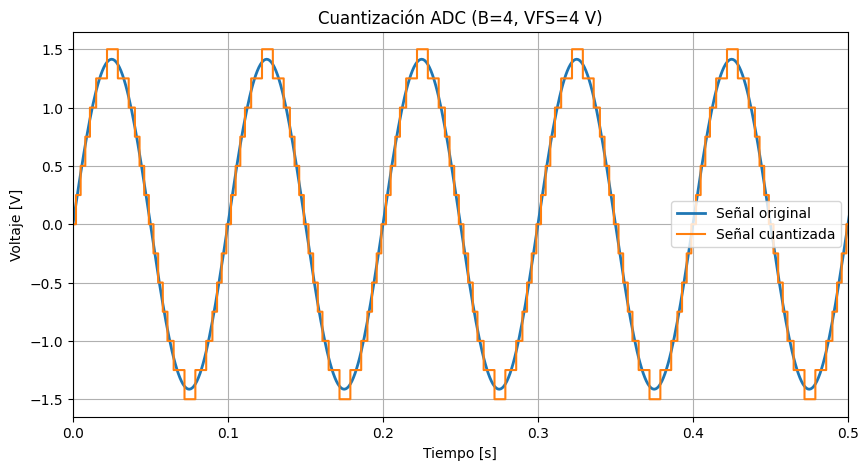

In [148]:
B = 4
sQ = cuantizador(sR = sR, B = B, VFS = VFS, adc = 'bipolar')

#%% Grafico Temporal
plt.figure(figsize=(10,5))
plt.plot(t, sR, label='Señal original', linewidth=2)
plt.plot(t, sQ, drawstyle='steps-post', label='Señal cuantizada')
plt.title(f"Cuantización ADC (B={B}, VFS={VFS} V)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.xlim(0, 5/ff)
plt.grid()
plt.legend()
plt.show()

### Ruido de Cuantizacion (B = 4)

       CARACTERIZACIÓN DEL RUIDO
  Media:                    9.6617e-17
  Varianza:                 5.8321e-03
  Potencia medida:          5.8321e-03
  Potencia ideal (q²/12):   5.2083e-03
  SNR:                      22.34 dB


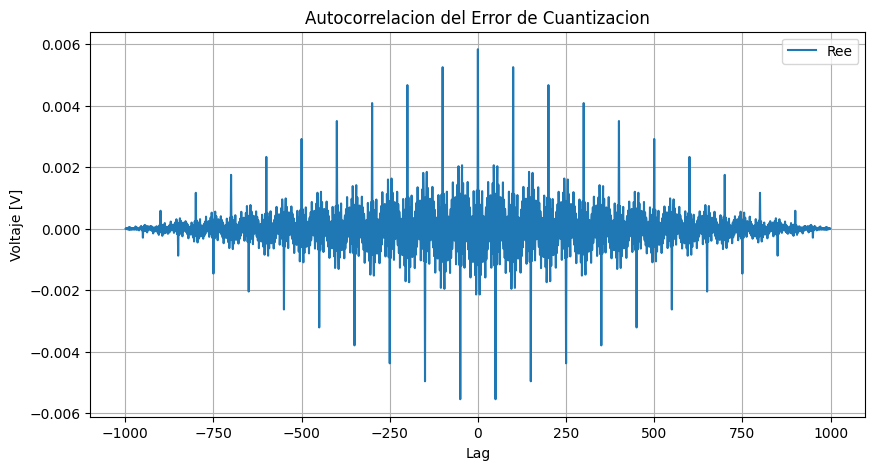

In [149]:
e = sQ - sR
ree = np.correlate(e, e, mode='full') / N
p_quant = ree[N-1] # P = ree(0)

q = VFS / (2**B)

print("=" * 45)
print("       CARACTERIZACIÓN DEL RUIDO")
print("=" * 45)
print(f"  Media:                    {np.mean(e):.4e}")
print(f"  Varianza:                 {np.var(e):.4e}")
print(f"  Potencia medida:          {p_quant:.4e}")
print(f"  Potencia ideal (q²/12):   {q**2/12:.4e}")
print(f"  SNR:                      {10*np.log10(p_signal/p_quant):.2f} dB")
print("=" * 45)

lags = np.arange(-(N-1), N) 
plt.figure(figsize=(10,5))

plt.plot(lags, ree, label='Ree', linewidth=1.5)
plt.title("Autocorrelacion del Error de Cuantizacion")
plt.xlabel("Lag")
plt.ylabel("Voltaje [V]")
plt.grid()
plt.legend()
plt.show()

### PSD de la Señal y Ruido de Cuantización (B = 4):

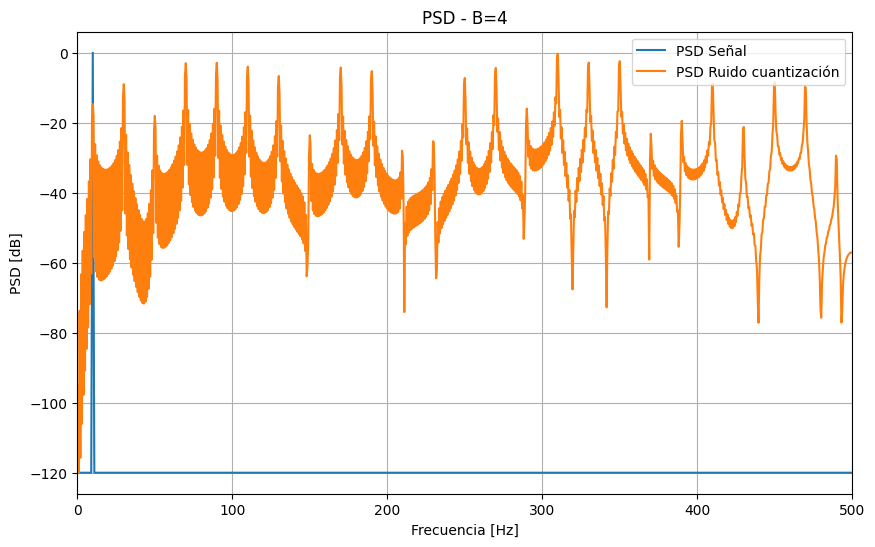

In [150]:
Xk = np.fft.fft(sR)
See = np.fft.fft(ree)
f     = np.arange(start = 0, stop = fs, step = deltaf)
f_see = np.arange(start = 0, stop = fs, step = deltaf/2)
f_see = f_see[:-1]
          
plt.figure(figsize=(10,6))
plt.plot(f, 10*np.log10(2*((np.abs(Xk)/N)**2) + 1e-12), label='PSD Señal')
plt.plot(f_see, 10*np.log10(2*np.abs(See) + 1e-12), label='PSD Ruido cuantización')
plt.title(f"PSD - B={B}")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.xlim(0,fs/2)
plt.grid()
plt.legend()
plt.show()

### Cuantizacion 8 Bits:

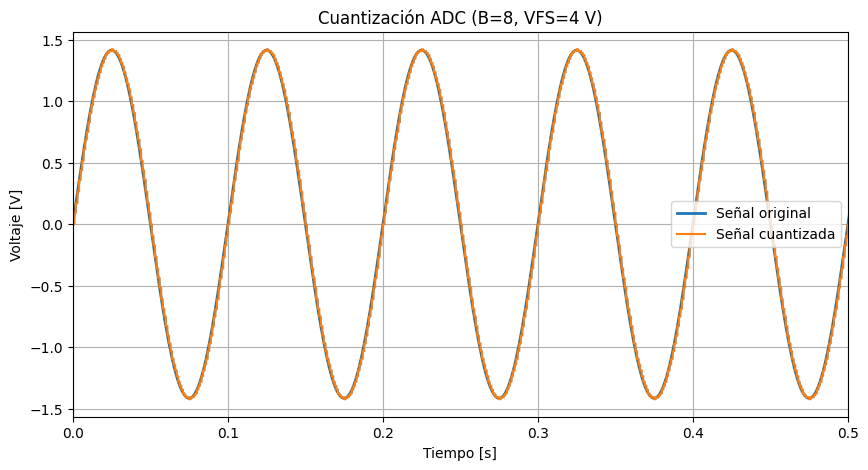

In [151]:
B = 8
sQ = cuantizador(sR = sR, B = B, VFS = VFS, adc = 'bipolar')
e = sQ - sR
p_quant = np.mean(e**2)

#%% Grafico Temporal
plt.figure(figsize=(10,5))
plt.plot(t, sR, label='Señal original', linewidth=2)
plt.plot(t, sQ, drawstyle='steps-post', label='Señal cuantizada')
plt.title(f"Cuantización ADC (B={B}, VFS={VFS} V)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.xlim(0, 5/ff)
plt.grid()
plt.legend()
plt.show()

### Ruido de Cuantizacion (B = 8)

       CARACTERIZACIÓN DEL RUIDO
  Media:                    9.6621e-17
  Varianza:                 2.0953e-05
  Potencia medida:          2.0953e-05
  Potencia ideal (q²/12):   2.0345e-05
  SNR:                      46.79 dB


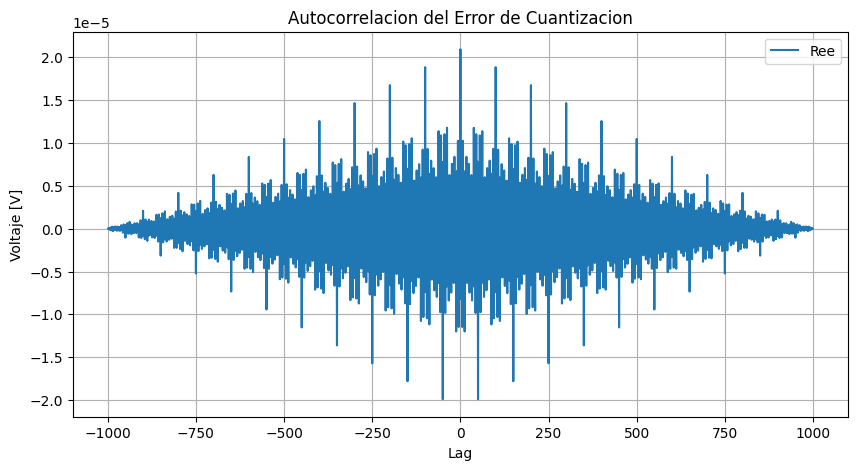

In [152]:
e = sQ - sR
ree = np.correlate(e, e, mode='full') / N
p_quant = ree[N-1] # P = ree(0)

q = VFS / (2**B)

print("=" * 45)
print("       CARACTERIZACIÓN DEL RUIDO")
print("=" * 45)
print(f"  Media:                    {np.mean(e):.4e}")
print(f"  Varianza:                 {np.var(e):.4e}")
print(f"  Potencia medida:          {p_quant:.4e}")
print(f"  Potencia ideal (q²/12):   {q**2/12:.4e}")
print(f"  SNR:                      {10*np.log10(p_signal/p_quant):.2f} dB")
print("=" * 45)

lags = np.arange(-(N-1), N) 
plt.figure(figsize=(10,5))

plt.plot(lags, ree, label='Ree', linewidth=1.5)
plt.title("Autocorrelacion del Error de Cuantizacion")
plt.xlabel("Lag")
plt.ylabel("Voltaje [V]")
plt.grid()
plt.legend()
plt.show()

### PSD de la Señal y Ruido de Cuantización (B = 8):

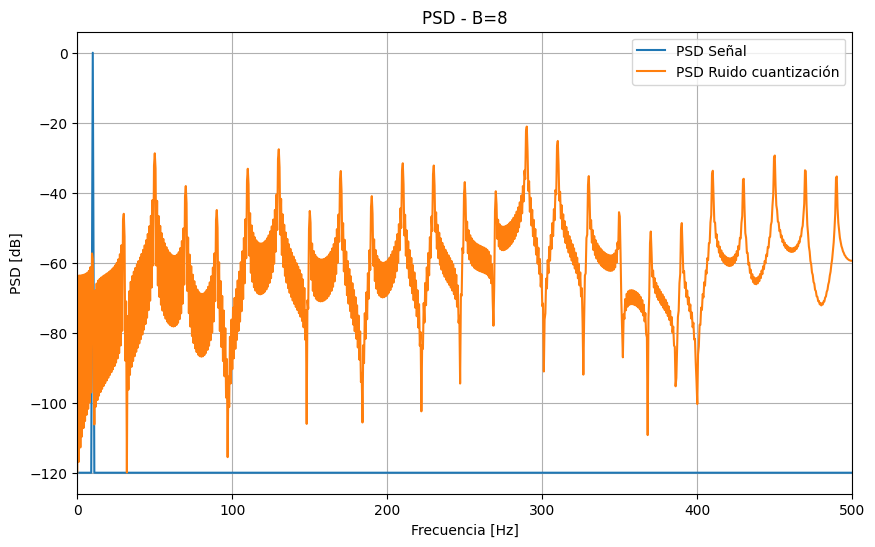

In [153]:
Xk = np.fft.fft(sR)
See = np.fft.fft(ree)
f     = np.arange(start = 0, stop = fs, step = deltaf)
f_see = np.arange(start = 0, stop = fs, step = deltaf/2)
f_see = f_see[:-1]
          
plt.figure(figsize=(10,6))
plt.plot(f, 10*np.log10(2*((np.abs(Xk)/N)**2) + 1e-12), label='PSD Señal')
plt.plot(f_see, 10*np.log10(2*np.abs(See) + 1e-12), label='PSD Ruido cuantización')
plt.title(f"PSD - B={B}")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.xlim(0,fs/2)
plt.grid()
plt.legend()
plt.show()

### Cuantizacion 16 Bits:

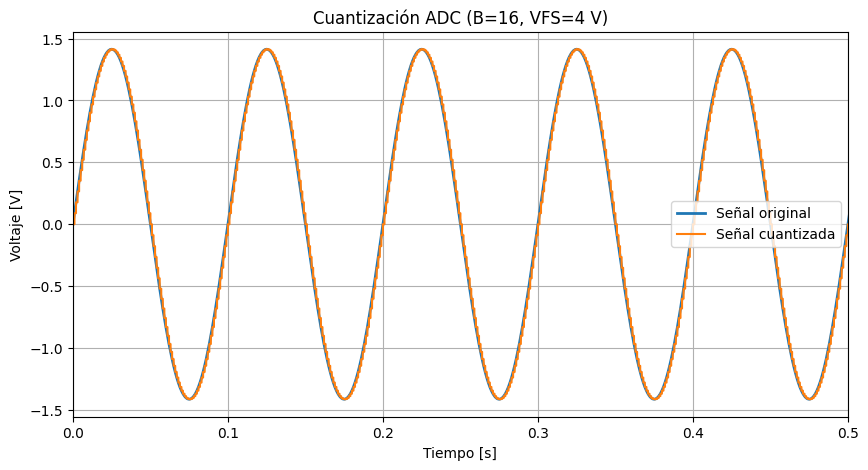

In [154]:
B = 16
sQ = cuantizador(sR = sR, B = B, VFS = VFS, adc = 'bipolar')
e = sQ - sR
p_quant = np.mean(e**2)

#%% Grafico Temporal
plt.figure(figsize=(10,5))
plt.plot(t, sR, label='Señal original', linewidth=2)
plt.plot(t, sQ, drawstyle='steps-post', label='Señal cuantizada')
plt.title(f"Cuantización ADC (B={B}, VFS={VFS} V)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.xlim(0, 5/ff)
plt.grid()
plt.legend()
plt.show()

### Ruido de Cuantización (B = 16)

       CARACTERIZACIÓN DEL RUIDO
  Media:                    9.6620e-17
  Varianza:                 4.1883e-10
  Potencia medida:          4.1883e-10
  Potencia ideal (q²/12):   3.1044e-10
  SNR:                      93.78 dB


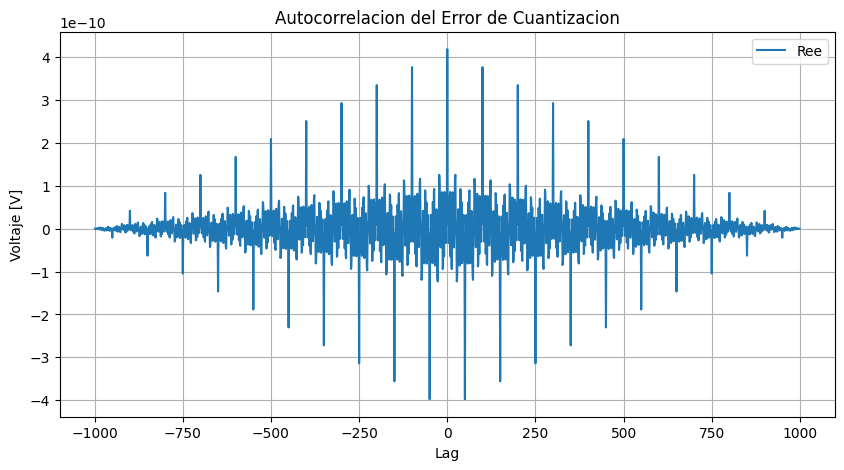

In [155]:
e = sQ - sR
ree = np.correlate(e, e, mode='full') / N
p_quant = ree[N-1] # P = ree(0)

q = VFS / (2**B)

print("=" * 45)
print("       CARACTERIZACIÓN DEL RUIDO")
print("=" * 45)
print(f"  Media:                    {np.mean(e):.4e}")
print(f"  Varianza:                 {np.var(e):.4e}")
print(f"  Potencia medida:          {p_quant:.4e}")
print(f"  Potencia ideal (q²/12):   {q**2/12:.4e}")
print(f"  SNR:                      {10*np.log10(p_signal/p_quant):.2f} dB")
print("=" * 45)

lags = np.arange(-(N-1), N) 
plt.figure(figsize=(10,5))

plt.plot(lags, ree, label='Ree', linewidth=1.5)
plt.title("Autocorrelacion del Error de Cuantizacion")
plt.xlabel("Lag")
plt.ylabel("Voltaje [V]")
plt.grid()
plt.legend()
plt.show()

### PSD de la Señal y Ruido de Cuantización (B = 16):

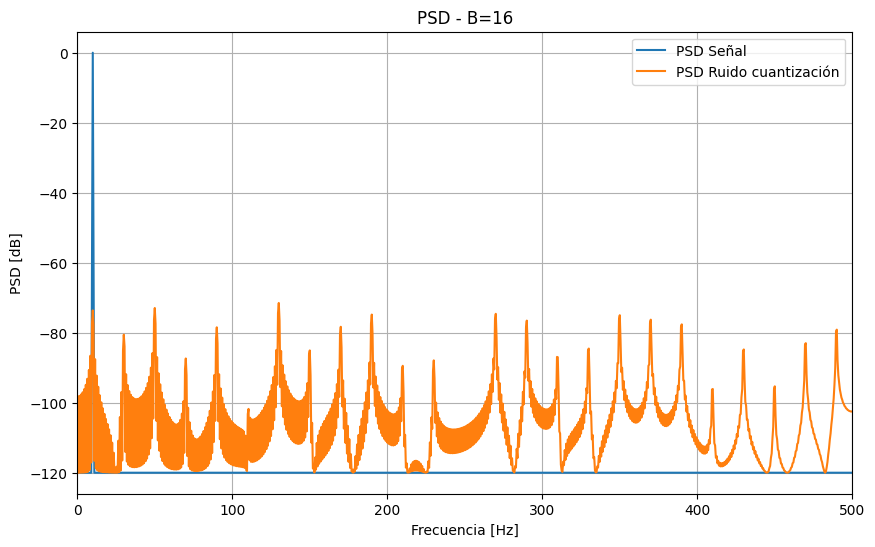

In [156]:
Xk = np.fft.fft(sR)
See = np.fft.fft(ree)
f     = np.arange(start = 0, stop = fs, step = deltaf)
f_see = np.arange(start = 0, stop = fs, step = deltaf/2)
f_see = f_see[:-1]
          
plt.figure(figsize=(10,6))
plt.plot(f, 10*np.log10(2*((np.abs(Xk)/N)**2) + 1e-12), label='PSD Señal')
plt.plot(f_see, 10*np.log10(2*np.abs(See) + 1e-12), label='PSD Ruido cuantización')
plt.title(f"PSD - B={B}")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.xlim(0,fs/2)
plt.grid()
plt.legend()
plt.show()

## Bonus:

Como se pudo observar en los casos anteriores la distribución del ruido de cuantización no es uniforme. Lo podemos notar al observar que su autocorrelación no es una delta en Ree[0]. Esto se debe a que la señal cuantizada es deterministica. Si buscamos que nuestra distribución de ruido de cuantización se aproxime a más a una distribución uniforme debemos agregar ruido aleatorio a nuestra señal muestreada. Para esta experimentación utilizaremos B = 8.

### Función Ruido Normal

In [157]:
def nnoise(nn=1000, fs=1000, mean=0, std=1):
    
    tt  = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    ww  = np.random.normal(loc=mean, scale=std, size= nn)
    return tt, ww

### SNR = 100db

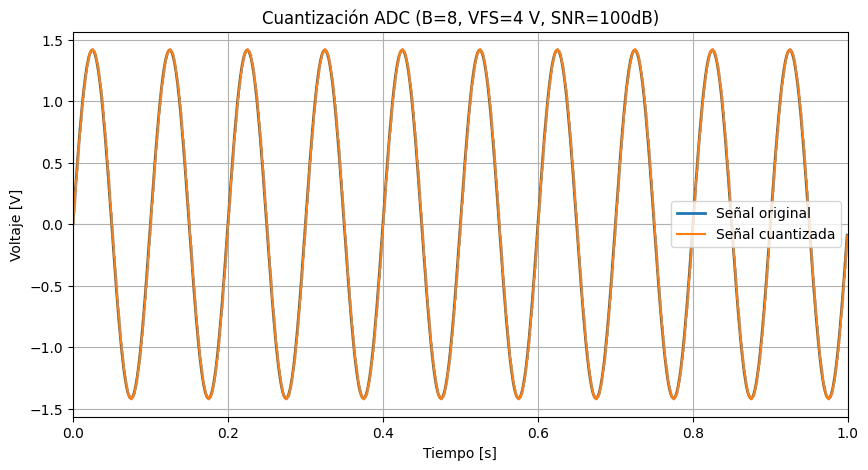

In [158]:
B = 8
SNR = 100

p_noise  = p_signal / (10 ** (SNR / 10))
std_noise  = np.sqrt(p_noise)
_, sN = nnoise(nn = N, fs=fs, mean=0, std=std_noise)
p_noise = np.mean(sN**2)

sRN = sR + sN

sQ = cuantizador(sR = sRN, B = B, VFS = VFS, adc = 'bipolar')

#%% Grafico Temporal
plt.figure(figsize=(10,5))
plt.plot(t, sRN, label='Señal original', linewidth=2)
plt.plot(t, sQ, drawstyle='steps-post', label='Señal cuantizada')
plt.title(f"Cuantización ADC (B={B}, VFS={VFS} V, SNR={SNR}dB)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.xlim(0, 10/ff)
plt.grid()
plt.legend()
plt.show()

#### Ruido de Cuantización (SNR = 100db)

       CARACTERIZACIÓN DEL RUIDO
  Media:                    9.6621e-17
  Varianza:                 2.0953e-05
  Potencia medida:          2.0953e-05
  Potencia ideal (q²/12):   2.0345e-05
  SNR:                      46.79 dB


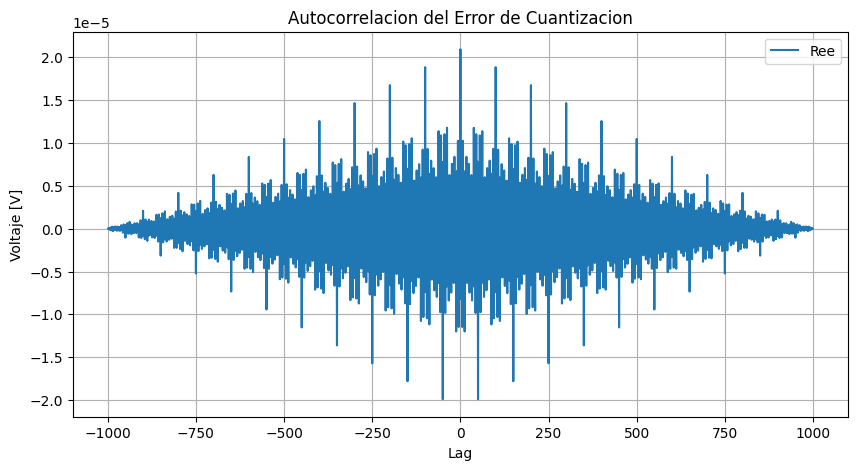

In [159]:
e = sQ - sR
ree = np.correlate(e, e, mode='full') / N
p_quant = ree[N-1] # P = ree(0)
sNQ = sN + e
p_nq = np.mean(sNQ**2)

q = VFS / (2**B)

print("=" * 45)
print("       CARACTERIZACIÓN DEL RUIDO")
print("=" * 45)
print(f"  Media:                    {np.mean(e):.4e}")
print(f"  Varianza:                 {np.var(e):.4e}")
print(f"  Potencia medida:          {p_quant:.4e}")
print(f"  Potencia ideal (q²/12):   {q**2/12:.4e}")
print(f"  SNR:                      {10*np.log10(p_signal/p_nq):.2f} dB")
print("=" * 45)

lags = np.arange(-(N-1), N) 
plt.figure(figsize=(10,5))

plt.plot(lags, ree, label='Ree', linewidth=1.5)
plt.title("Autocorrelacion del Error de Cuantizacion")
plt.xlabel("Lag")
plt.ylabel("Voltaje [V]")
plt.grid()
plt.legend()
plt.show()

#### PSD de la Señal y Ruido de Cuantización (SNR = 100db):

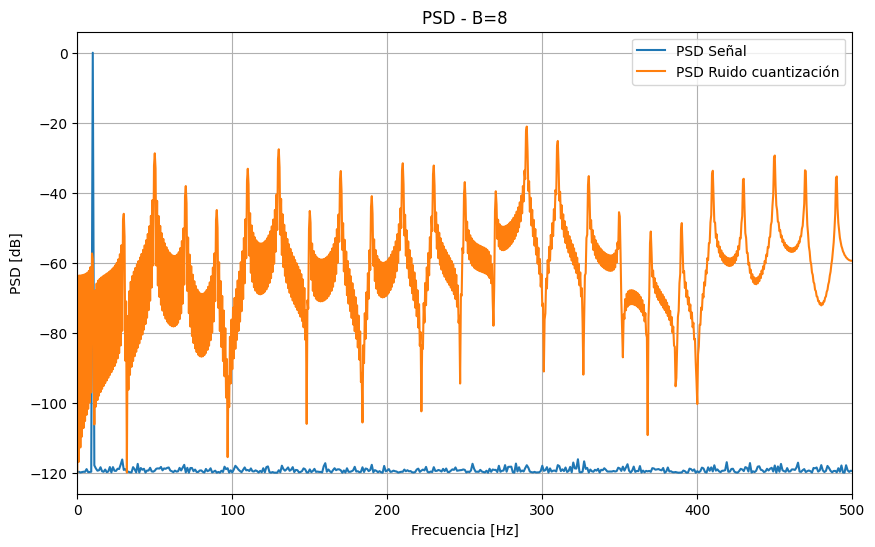

In [160]:
Xk = np.fft.fft(sRN)
See = np.fft.fft(ree)
f     = np.arange(start = 0, stop = fs, step = deltaf)
f_see = np.arange(start = 0, stop = fs, step = deltaf/2)
f_see = f_see[:-1]
          
plt.figure(figsize=(10,6))
plt.plot(f, 10*np.log10(2*((np.abs(Xk)/N)**2) + 1e-12), label='PSD Señal')
plt.plot(f_see, 10*np.log10(2*np.abs(See) + 1e-12), label='PSD Ruido cuantización')
plt.title(f"PSD - B={B}")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.xlim(0,fs/2)
plt.grid()
plt.legend()
plt.show()

Se observa que si el ruido analogico es mucho menor al ruido de cuantización no modifica considerablemente la distribución del ruido de cuantificación y la SNR queda limitada por la cantidad de bits.

### SNR = 45db

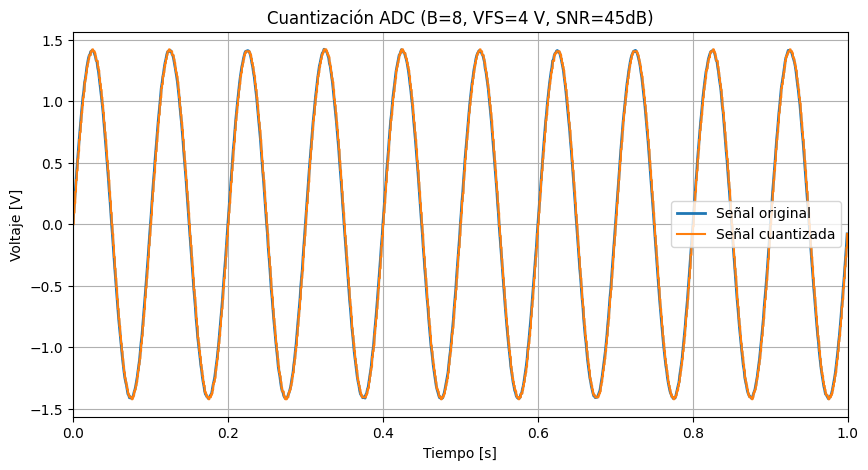

In [161]:
B = 8
SNR = 45

p_noise  = p_signal / (10 ** (SNR / 10))
std_noise  = np.sqrt(p_noise)
_, sN = nnoise(nn = N, fs=fs, mean=0, std=std_noise)
p_noise = np.mean(sN**2)

sRN = sR + sN

sQ = cuantizador(sR = sRN, B = B, VFS = VFS, adc = 'bipolar')

#%% Grafico Temporal
plt.figure(figsize=(10,5))
plt.plot(t, sRN, label='Señal original', linewidth=2)
plt.plot(t, sQ, drawstyle='steps-post', label='Señal cuantizada')
plt.title(f"Cuantización ADC (B={B}, VFS={VFS} V, SNR={SNR}dB)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.xlim(0, 10/ff)
plt.grid()
plt.legend()
plt.show()

#### Ruido de Cuantización (SNR = 45db)

       CARACTERIZACIÓN DEL RUIDO
  Media:                    -1.5625e-04
  Varianza:                 4.7999e-05
  Potencia medida:          4.8023e-05
  Potencia ideal (q²/12):   2.0345e-05
  SNR:                      38.69 dB


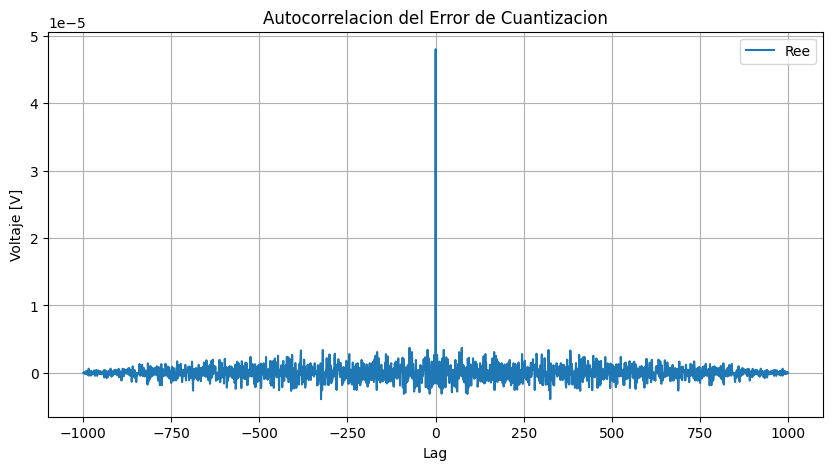

In [162]:
e = sQ - sR
ree = np.correlate(e, e, mode='full') / N
p_quant = ree[N-1] # P = ree(0)
sNQ = sN + e
p_nq = np.mean(sNQ**2)

q = VFS / (2**B)

print("=" * 45)
print("       CARACTERIZACIÓN DEL RUIDO")
print("=" * 45)
print(f"  Media:                    {np.mean(e):.4e}")
print(f"  Varianza:                 {np.var(e):.4e}")
print(f"  Potencia medida:          {p_quant:.4e}")
print(f"  Potencia ideal (q²/12):   {q**2/12:.4e}")
print(f"  SNR:                      {10*np.log10(p_signal/p_nq):.2f} dB")
print("=" * 45)

lags = np.arange(-(N-1), N) 
plt.figure(figsize=(10,5))

plt.plot(lags, ree, label='Ree', linewidth=1.5)
plt.title("Autocorrelacion del Error de Cuantizacion")
plt.xlabel("Lag")
plt.ylabel("Voltaje [V]")
plt.grid()
plt.legend()
plt.show()

#### PSD de la Señal y Ruido de Cuantización (SNR = 45db):

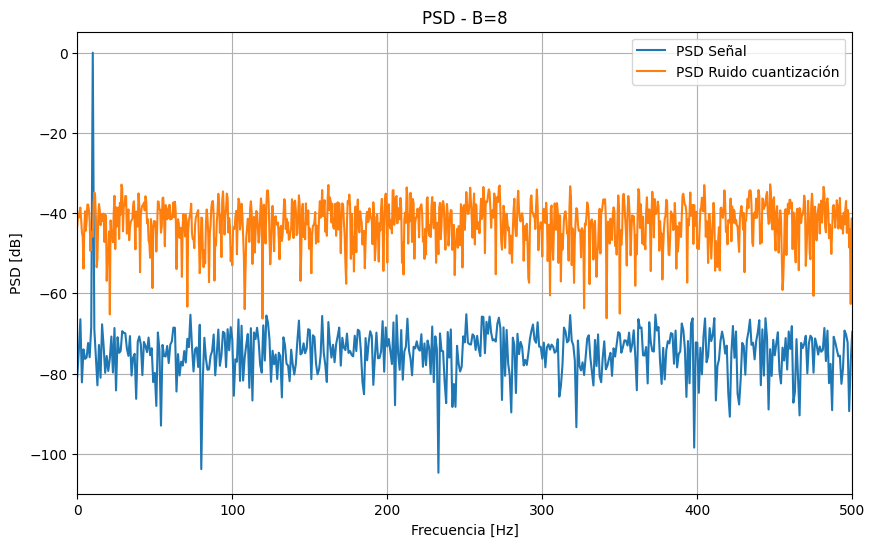

In [163]:
Xk = np.fft.fft(sRN)
See = np.fft.fft(ree)
f     = np.arange(start = 0, stop = fs, step = deltaf)
f_see = np.arange(start = 0, stop = fs, step = deltaf/2)
f_see = f_see[:-1]
          
plt.figure(figsize=(10,6))
plt.plot(f, 10*np.log10(2*((np.abs(Xk)/N)**2) + 1e-12), label='PSD Señal')
plt.plot(f_see, 10*np.log10(2*np.abs(See) + 1e-12), label='PSD Ruido cuantización')
plt.title(f"PSD - B={B}")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.xlim(0,fs/2)
plt.grid()
plt.legend()
plt.show()

Cuando el ruido adicionado es aproximadamente de la misma magnitud del ruido de cuantización, la autocorrelacion del ultimo se aproxima a una delta y por lo tanto, exhibe una caracteristica mas uniforme en frecuencia. En este caso la SNR total se ve afectada por ambos ruidos.

### SNR = 15db

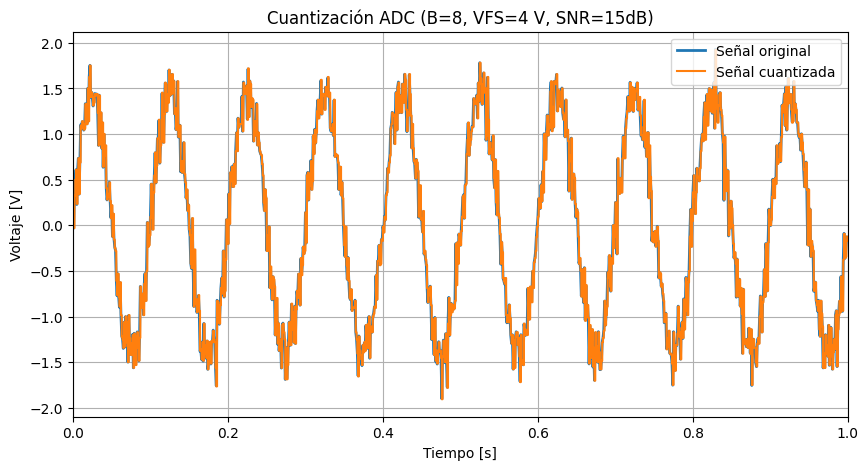

In [164]:
B = 8
SNR = 15

p_noise  = p_signal / (10 ** (SNR / 10))
std_noise  = np.sqrt(p_noise)
_, sN = nnoise(nn = N, fs=fs, mean=0, std=std_noise)
p_noise = np.mean(sN**2)

sRN = sR + sN

sQ = cuantizador(sR = sRN, B = B, VFS = VFS, adc = 'bipolar')

#%% Grafico Temporal
plt.figure(figsize=(10,5))
plt.plot(t, sRN, label='Señal original', linewidth=2)
plt.plot(t, sQ, drawstyle='steps-post', label='Señal cuantizada')
plt.title(f"Cuantización ADC (B={B}, VFS={VFS} V, SNR={SNR}dB)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.xlim(0, 10/ff)
plt.grid()
plt.legend()
plt.show()

#### Ruido de Cuantización (SNR = 15db)

       CARACTERIZACIÓN DEL RUIDO
  Media:                    9.4375e-03
  Varianza:                 3.2311e-02
  Potencia medida:          3.2400e-02
  Potencia ideal (q²/12):   2.0345e-05
  SNR:                      8.88 dB


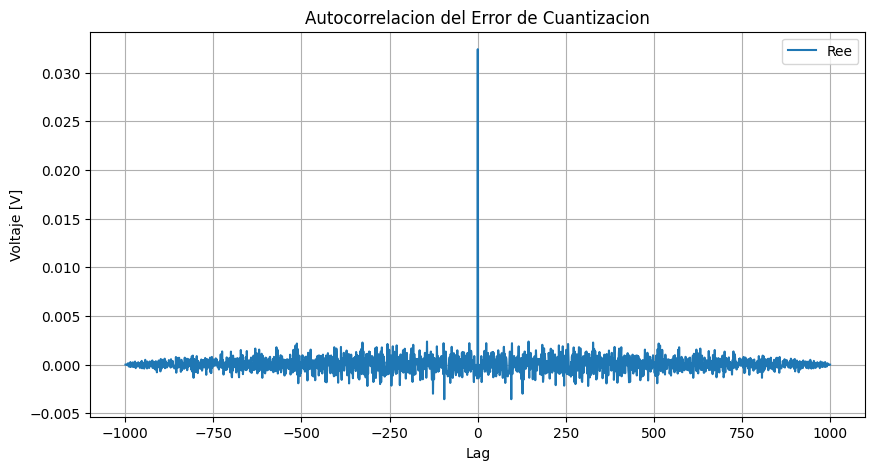

In [165]:
e = sQ - sR
ree = np.correlate(e, e, mode='full') / N
p_quant = ree[N-1] # P = ree(0)
sNQ = sN + e
p_nq = np.mean(sNQ**2)

q = VFS / (2**B)

print("=" * 45)
print("       CARACTERIZACIÓN DEL RUIDO")
print("=" * 45)
print(f"  Media:                    {np.mean(e):.4e}")
print(f"  Varianza:                 {np.var(e):.4e}")
print(f"  Potencia medida:          {p_quant:.4e}")
print(f"  Potencia ideal (q²/12):   {q**2/12:.4e}")
print(f"  SNR:                      {10*np.log10(p_signal/p_nq):.2f} dB")
print("=" * 45)

lags = np.arange(-(N-1), N) 
plt.figure(figsize=(10,5))

plt.plot(lags, ree, label='Ree', linewidth=1.5)
plt.title("Autocorrelacion del Error de Cuantizacion")
plt.xlabel("Lag")
plt.ylabel("Voltaje [V]")
plt.grid()
plt.legend()
plt.show()

#### PSD de la Señal y Ruido de Cuantización (SNR = 15db):

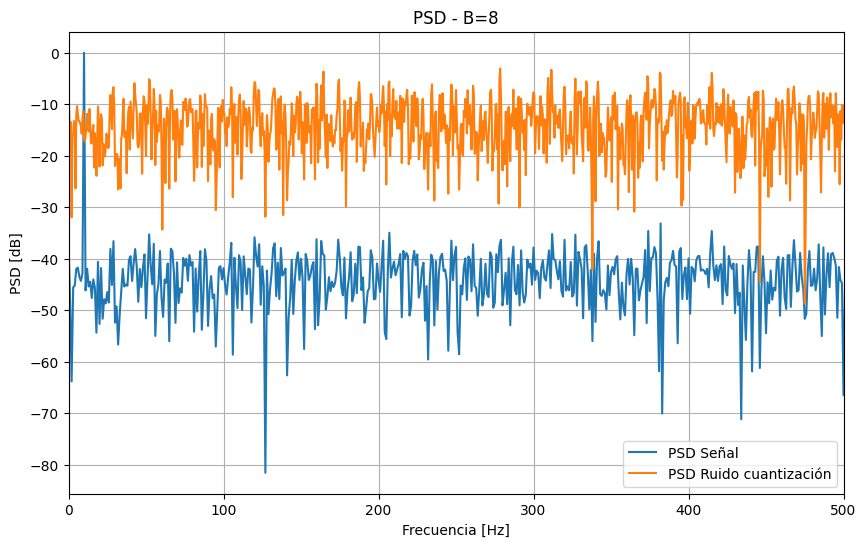

In [166]:
Xk = np.fft.fft(sRN)
See = np.fft.fft(ree)
f     = np.arange(start = 0, stop = fs, step = deltaf)
f_see = np.arange(start = 0, stop = fs, step = deltaf/2)
f_see = f_see[:-1]
          
plt.figure(figsize=(10,6))
plt.plot(f, 10*np.log10(2*((np.abs(Xk)/N)**2) + 1e-12), label='PSD Señal')
plt.plot(f_see, 10*np.log10(2*np.abs(See) + 1e-12), label='PSD Ruido cuantización')
plt.title(f"PSD - B={B}")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.xlim(0,fs/2)
plt.grid()
plt.legend()
plt.show()

En este último caso podemos notar un aumento del fenomeno del caso anterior. Es decir, el ruido de cuantización es cada vez mas uniforme cuanto menos deterministica es la señal. Concluimos entonces que al momento de la selección del ADC es importante tener conocimiento del ruido analogico de la señal. De esta forma evitamos gastos inecesarios o generamos un deterioro considerable de la calidad de la señal.